This TEST notebook is exploratory. The goal is to experiment with charts to get an overview of the data and find more questions to base additional calculations off of.  
END OF DAY 1 NOTE: Need to find the year range for the data. Need to explore average by industry bar chart to see if that is counting any level of AI adoption and look at risk management score column

In [103]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sqlite3


In [104]:
#Create dataframes
df_industry = pd.read_csv("../Data/ai_industry_summary.csv") 

In [105]:
df_company = pd.read_csv("../Data/ai_company_adoption.csv") 

In [106]:
df_country = pd.read_csv("../Data/country_ai_index.csv")

Text(0, 0.5, 'Average AI Adoption %')

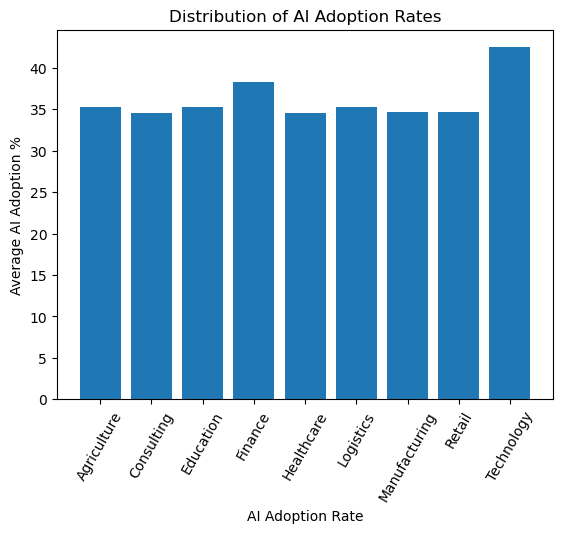

In [107]:
# Plot bar chart of AI Adoption Rates by Industry #Note: need to explore data more to see if it means any level of AI adoption
plt.bar(df_industry['industry'], df_industry["avg_ai_adoption_rate"])
plt.title("Distribution of AI Adoption Rates")
plt.xticks(rotation=60)
plt.xlabel("AI Adoption Rate")
plt.ylabel("Average AI Adoption %")

The bar chart above answers the question of how percentage of adoption is spread over different industry. 

In [108]:
# Group by country and industry and then focus in on the ai adoption rate .mean()
country_industry = (
    df_company
    .groupby(["country", "industry"])["ai_adoption_rate"]
    .mean()
    .reset_index()
)

country_industry.head()

,country,industry,ai_adoption_rate
0,Argentina,Agriculture,32.432380
1,Argentina,Consulting,36.357964
2,Argentina,Education,30.827514
3,Argentina,Finance,38.770831
4,Argentina,Healthcare,30.699859


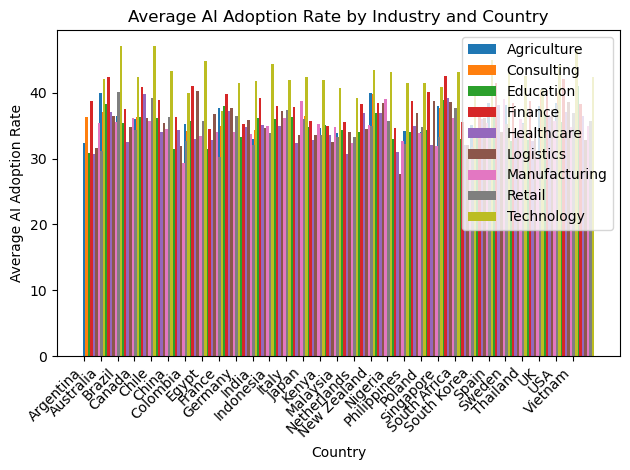

In [109]:
# DO NOT USE
# This ended up not being a great chart because there are too many bars
import matplotlib.pyplot as plt
import numpy as np

countries = country_industry["country"].unique()
industries = country_industry["industry"].unique()

x = np.arange(len(countries))

width = 0.15

for i, industry in enumerate(industries):
    
    data = country_industry[
        country_industry["industry"] == industry
    ]

    plt.bar(
        x + i * width,
        data["ai_adoption_rate"],
        width,
        label=industry
    )

plt.xticks(
    x,
    countries,
    rotation=45,
    ha="right"
)

plt.xlabel("Country")
plt.ylabel("Average AI Adoption Rate")
plt.title("Average AI Adoption Rate by Industry and Country")

plt.legend()
plt.tight_layout()

plt.show()

In [110]:
heatmap_data = df_company.pivot_table(
    index="country",
    columns="industry",
    values="ai_adoption_rate",
    aggfunc="mean"
)

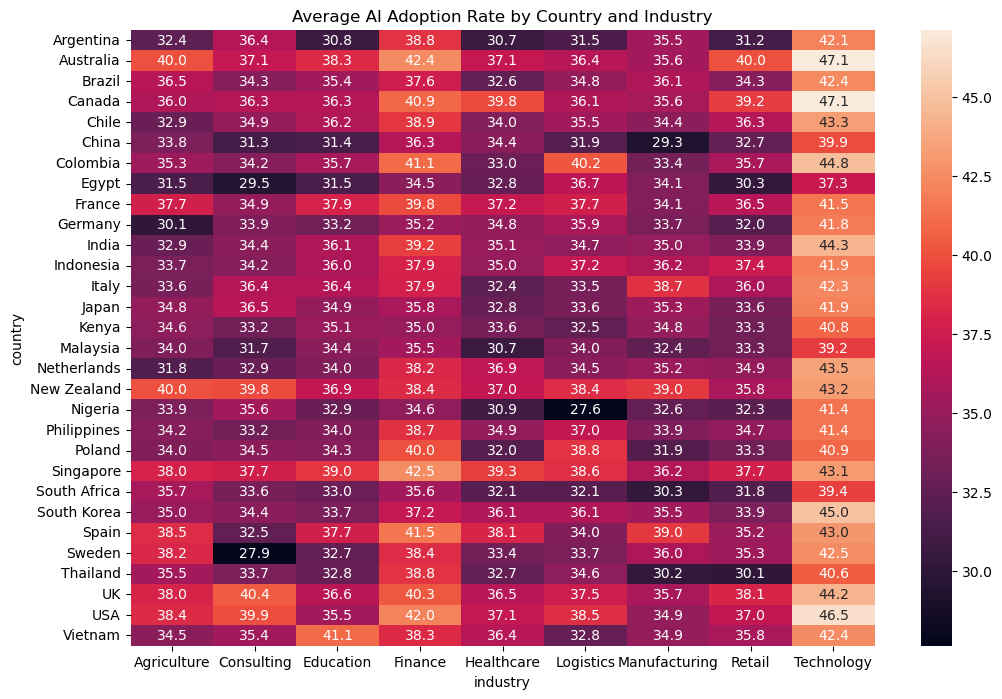

In [111]:
# Do not Use. Too overwhelming to look at
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f"
)

plt.title("Average AI Adoption Rate by Country and Industry")

plt.show()

In [112]:
#calculation for choropleth
country_ai = (
    df_company
    .groupby("country")["ai_adoption_rate"]
    .mean()
    .reset_index()
)

country_ai.head()

,country,ai_adoption_rate
0,Argentina,34.327419
1,Australia,39.933564
2,Brazil,36.674198
3,Canada,39.120333
4,Chile,36.461705


In [113]:
# USE THIS BUT ADD MORE DETAIL
# Choropleth of world AI adoption
import plotly.express as px

fig = px.choropleth(
    country_ai,
    locations="country",
    locationmode="country names",
    color="ai_adoption_rate",
    hover_name="country",
    title="Global Average AI Adoption Rate"
)

fig.show()

C:\Users\patri\AppData\Local\Temp\ipykernel_31940\1761818179.py:5: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [114]:
fig = px.choropleth(
    country_ai,
    locations="country",
    locationmode="country names",
    color="ai_adoption_rate",
    hover_name="country",
    color_continuous_scale="Plasma",
    range_color=(30,41),
    projection="natural earth",
    labels={
        "ai_adoption_rate": "Avg AI Adoption Rate (%)"
    },
    title="Global AI Adoption Intensity by Country"
)


fig.update_traces(
    marker_line_color="white",
    marker_line_width=0.4,
    hovertemplate=
        "<b>%{hovertext}</b><br>" +
        "AI Adoption Rate: %{z:.1f}%<extra></extra>"
)


fig.update_layout(

    # background
    paper_bgcolor="rgb(245,248,250)",
    plot_bgcolor="rgb(245,248,250)",

    title={
        "text": "Global AI Adoption Intensity by Country",
        "x": .5,
        "xanchor": "center",
        "font": {
            "size": 24,
            "color": "rgb(30,30,30)"
        }
    },

    geo=dict(
        showframe=False,
        showcoastlines=True,

        # the good stuff
        showocean=True,
        oceancolor="#3FAAA5",

        showland=True,
        landcolor="rgb(215,220,220)",

        coastlinecolor="white",
        countrycolor="white",

        projection_type="natural earth"
    ),

    coloraxis_colorbar=dict(
        title="AI Adoption<br>Rate (%)",
        ticksuffix="%",
        thickness=15
    ),

    margin=dict(
        l=20,
        r=20,
        t=70,
        b=20
    )
)


fig.show()

C:\Users\patri\AppData\Local\Temp\ipykernel_31940\15320097.py:1: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



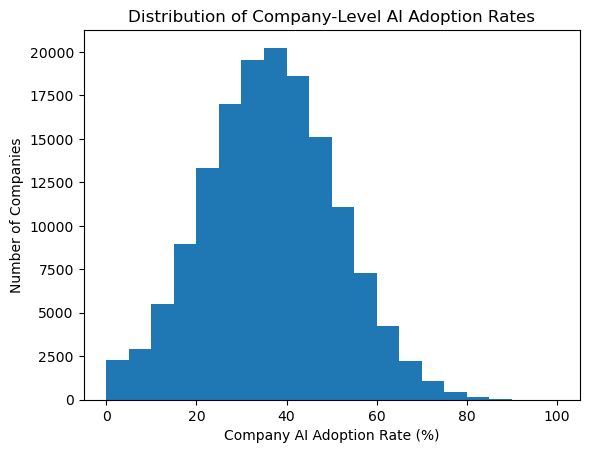

In [115]:
plt.hist(
    df_company["ai_adoption_rate"],
    bins=20
)

plt.xlabel("Company AI Adoption Rate (%)")
plt.ylabel("Number of Companies")
plt.title("Distribution of Company-Level AI Adoption Rates")

plt.show()

The above histogram shows us the distribution of company-level AI adoption rates. The bins are telling us what percentage of a company's workflows have been touched by AI. The y axis is the number of companies. 

In [116]:
#Shows how many companies sit at the different levels of AI adoption
stage_counts= df_company["ai_adoption_stage"].value_counts()

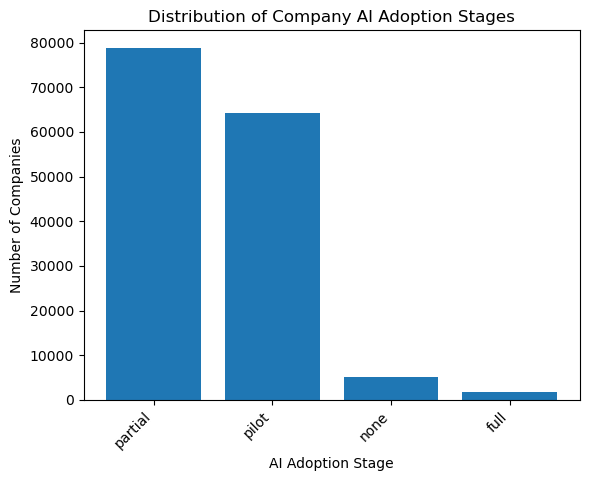

In [117]:
plt.bar(
    stage_counts.index,
    stage_counts.values
)

plt.title("Distribution of Company AI Adoption Stages")
plt.xlabel("AI Adoption Stage")
plt.ylabel("Number of Companies")

plt.xticks(rotation=45, ha="right")

plt.show()

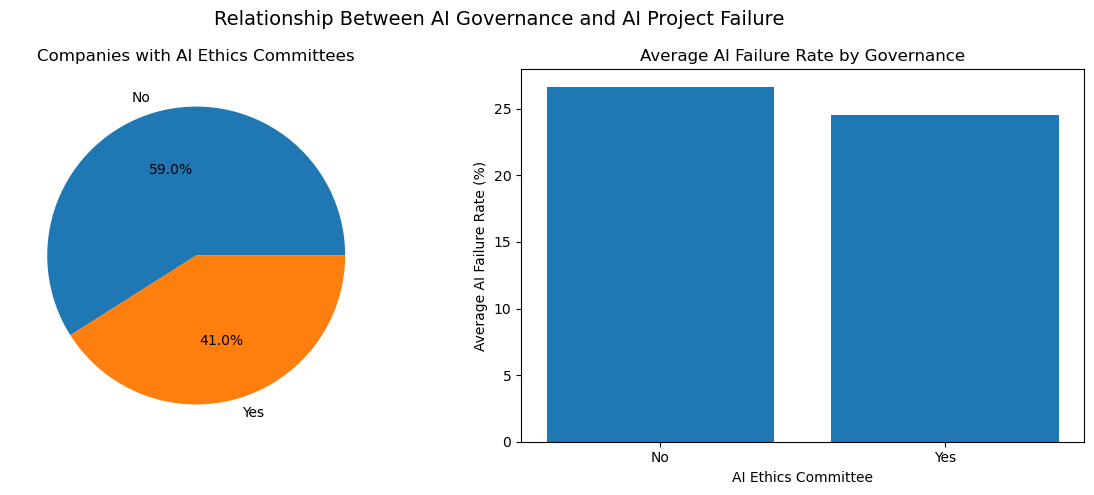

In [118]:
import matplotlib.pyplot as plt

# Count companies with/without AI ethics committee
committee_counts = df_company["ai_ethics_committee"].value_counts()

# Average AI failure rate by committee status
committee_failure = (
    df_company
    .groupby("ai_ethics_committee")["ai_failure_rate"]
    .mean()
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)


# LEFT: Pie chart
axes[0].pie(
    committee_counts,
    labels=committee_counts.index,
    autopct="%1.1f%%"
)

axes[0].set_title(
    "Companies with AI Ethics Committees"
)


# RIGHT: Failure 
axes[1].bar(
    committee_failure.index,
    committee_failure.values
)

axes[1].set_title(
    "Average AI Failure Rate by Governance"
)

axes[1].set_xlabel(
    "AI Ethics Committee"
)

axes[1].set_ylabel(
    "Average AI Failure Rate (%)"
)


# Main title
fig.suptitle(
    "Relationship Between AI Governance and AI Project Failure",
    fontsize=14
)

plt.tight_layout()

plt.show()

Above You can see that AI governance and project failure does not looks very significant. This makes me want to do a correlation matrix.


In [119]:
# I want to merge country to company for the correlation
ai_analysis = df_company.merge(
    df_country,
    on=["country", "region"],
    how="left"
)

ai_analysis.head()

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,innovation_score,customer_satisfaction,survey_source,data_collection_method,gdp_per_capita,internet_penetration,digital_maturity_index,country_ai_policy,ai_patent_filings_2024,ai_researchers_per_million
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,53,5.20,WEF Survey,API Scrape,39436.63,86.01,75.65,Moderate,2234,296.83
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,51,6.98,McKinsey Report,Phone Interview,39436.63,86.01,75.65,Moderate,2234,296.83
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,40,4.12,Internal Corporate Survey,Research Compilation,39436.63,86.01,75.65,Moderate,2234,296.83
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,...,51,5.72,Internal Corporate Survey,Research Compilation,39436.63,86.01,75.65,Moderate,2234,296.83
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,...,43,6.31,McKinsey Report,Research Compilation,39436.63,86.01,75.65,Moderate,2234,296.83


In [120]:
# For the merge we did not get any null values
ai_analysis.isnull().sum()

response_id                    0
company_id                     0
survey_year                    0
quarter                        0
country                        0
region                         0
industry                       0
company_size                   0
num_employees                  0
annual_revenue_usd_millions    0
company_founding_year          0
company_age                    0
company_age_group              0
ai_adoption_rate               0
ai_adoption_stage              0
years_using_ai                 0
ai_primary_tool                0
num_ai_tools_used              0
ai_use_case                    0
ai_projects_active             0
ai_training_hours              0
ai_budget_percentage           0
ai_maturity_score              0
ai_failure_rate                0
ai_investment_per_employee     0
regulatory_compliance_score    0
data_privacy_level             0
ai_ethics_committee            0
ai_risk_management_score       0
remote_work_percentage         0
employee_s

In [121]:
corr_df = ai_analysis[
    [
        # AI adoption 
        "ai_adoption_rate",
        "years_using_ai",
        "num_ai_tools_used",
        "ai_training_hours",
        "ai_budget_percentage",
        "ai_maturity_score",
        # Governance / risk
        "ai_failure_rate",
        "ai_risk_management_score",
        # Automation
        "task_automation_rate",
        # Business outcomes
        "productivity_change_percent",
        "revenue_growth_percent",
        "cost_reduction_percent",
        "innovation_score",
        "customer_satisfaction",
        # Workforce impact
        "jobs_created",
        "jobs_displaced",
        "reskilled_employees",
        "num_employees",
        # Country factors
        "gdp_per_capita",
        "internet_penetration",
        "digital_maturity_index",
        "ai_patent_filings_2024",
        "ai_researchers_per_million"
    ]
]

In [122]:
corr_matrix = corr_df.corr()

corr_matrix

,ai_adoption_rate,years_using_ai,num_ai_tools_used,ai_training_hours,ai_budget_percentage,ai_maturity_score,ai_failure_rate,ai_risk_management_score,task_automation_rate,productivity_change_percent,...,customer_satisfaction,jobs_created,jobs_displaced,reskilled_employees,num_employees,gdp_per_capita,internet_penetration,digital_maturity_index,ai_patent_filings_2024,ai_researchers_per_million
ai_adoption_rate,1.000000,0.194012,0.539365,0.728420,0.744476,0.841339,-0.657283,0.371078,0.703631,0.674973,...,0.422141,0.305982,0.278499,0.268673,0.179024,0.084071,0.065313,0.065344,0.020530,0.066572
years_using_ai,0.194012,1.000000,0.118055,0.134539,0.138527,0.155064,-0.098316,0.065638,0.134012,0.116494,...,0.068908,0.038894,0.034030,0.034274,0.023035,0.017045,0.012622,0.014992,0.010896,0.014742
num_ai_tools_used,0.539365,0.118055,1.000000,0.393811,0.400556,0.454016,-0.351571,0.201708,0.379691,0.364423,...,0.226932,0.164251,0.150138,0.144899,0.095097,0.045352,0.034089,0.033821,0.011109,0.035215
ai_training_hours,0.728420,0.134539,0.393811,1.000000,0.560236,0.821696,-0.739570,0.365538,0.513259,0.633740,...,0.415638,0.301574,0.275714,0.344071,0.212653,0.058913,0.045288,0.044919,0.012355,0.046201
ai_budget_percentage,0.744476,0.138527,0.400556,0.560236,1.000000,0.819248,-0.527048,0.367073,0.517041,0.604105,...,0.368443,0.356931,0.327195,0.321456,0.271892,0.058674,0.045336,0.043950,0.011948,0.046661
ai_maturity_score,0.841339,0.155064,0.454016,0.821696,0.819248,1.000000,-0.697749,0.445840,0.590048,0.737314,...,0.458789,0.398065,0.364793,0.388040,0.298857,0.065990,0.050482,0.049445,0.013477,0.051881
ai_failure_rate,-0.657283,-0.098316,-0.351571,-0.739570,-0.527048,-0.697749,1.000000,-0.312925,-0.462539,-0.593667,...,-0.434765,-0.259982,-0.237706,-0.272529,-0.179474,-0.055131,-0.043751,-0.042467,-0.012411,-0.043397
ai_risk_management_score,0.371078,0.065638,0.201708,0.365538,0.367073,0.445840,-0.312925,1.000000,0.258595,0.328775,...,0.204855,0.207998,0.190840,0.202653,0.167333,0.026329,0.022883,0.018935,0.002168,0.019227
task_automation_rate,0.703631,0.134012,0.379691,0.513259,0.517041,0.590048,-0.462539,0.258595,1.000000,0.582721,...,0.345878,0.216635,0.286413,0.190246,0.126533,0.062197,0.049653,0.051581,0.019071,0.052065
productivity_change_percent,0.674973,0.116494,0.364423,0.633740,0.604105,0.737314,-0.593667,0.328775,0.582721,1.000000,...,0.569821,0.291897,0.287572,0.282751,0.207824,0.051191,0.039234,0.040381,0.014018,0.040627


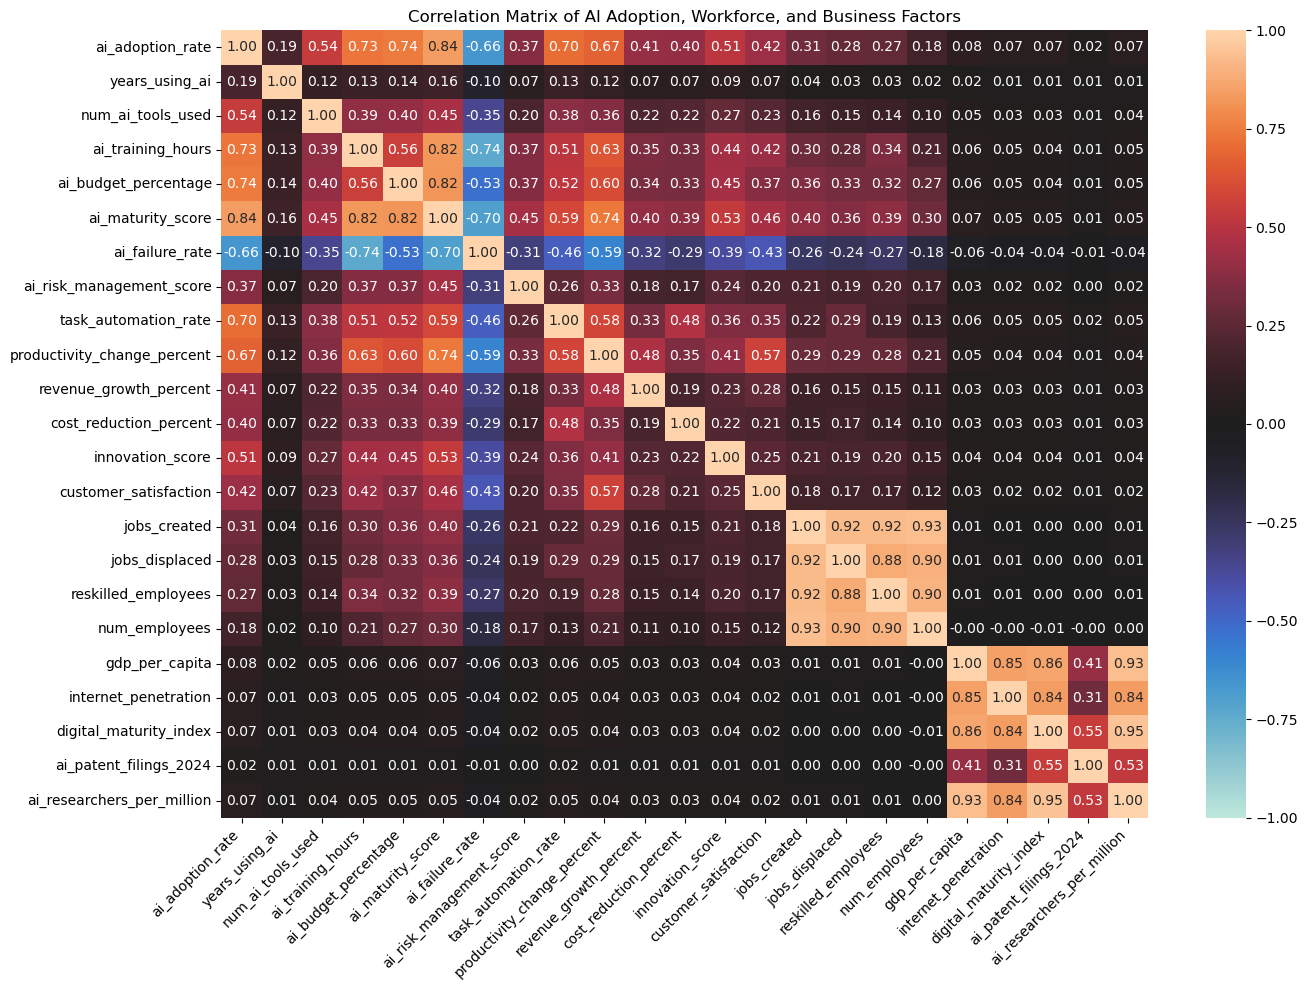

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title(
    "Correlation Matrix of AI Adoption, Workforce, and Business Factors"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

In [124]:
corr_pairs = (
    corr_matrix
    .unstack()
    .reset_index()
)

corr_pairs.columns = [
    "Variable 1",
    "Variable 2",
    "Correlation"
]

corr_pairs = corr_pairs[
    corr_pairs["Variable 1"] != corr_pairs["Variable 2"]
]

corr_pairs.sort_values(
    "Correlation",
    ascending=False
).head(10)

,Variable 1,Variable 2,Correlation
482,digital_maturity_index,ai_researchers_per_million,0.952405
526,ai_researchers_per_million,digital_maturity_index,0.952405
339,jobs_created,num_employees,0.932788
405,num_employees,jobs_created,0.932788
436,gdp_per_capita,ai_researchers_per_million,0.932110
524,ai_researchers_per_million,gdp_per_capita,0.932110
359,jobs_displaced,jobs_created,0.923838
337,jobs_created,jobs_displaced,0.923838
338,jobs_created,reskilled_employees,0.923788
382,reskilled_employees,jobs_created,0.923788


In [125]:
workforce = df_company[
    [
        "jobs_created",
        "jobs_displaced",
        "reskilled_employees"
    ]
]

workforce.head()

,jobs_created,jobs_displaced,reskilled_employees
0,1,1,3
1,2,2,5
2,3,3,2
3,1,1,2
4,3,2,6


In [126]:
workforce_corr = workforce.corr()

workforce_corr

,jobs_created,jobs_displaced,reskilled_employees
jobs_created,1.000000,0.923838,0.923788
jobs_displaced,0.923838,1.000000,0.876548
reskilled_employees,0.923788,0.876548,1.000000


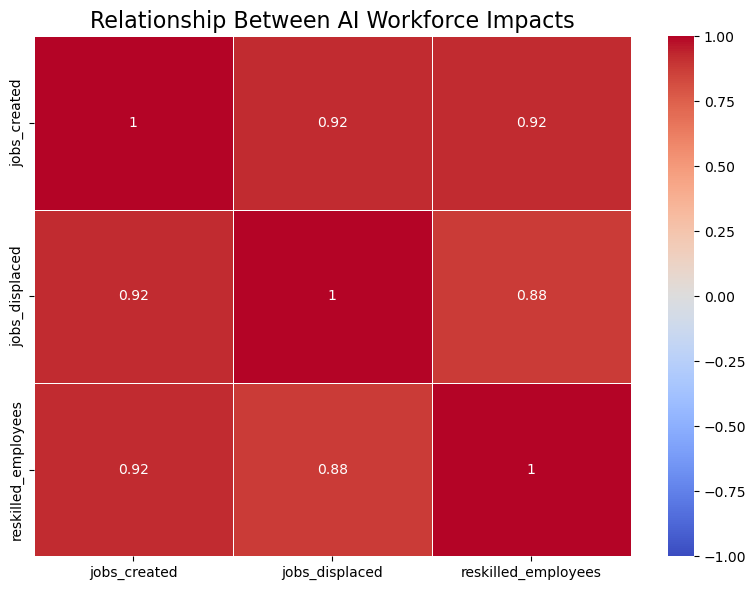

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    workforce_corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=.5
)

plt.title(
    "Relationship Between AI Workforce Impacts",
    fontsize=16
)

plt.tight_layout()

plt.show()

In [128]:
size_check = df_company[
    [
        "num_employees",
        "jobs_created",
        "jobs_displaced",
        "reskilled_employees"
    ]
]

size_check.corr()

,num_employees,jobs_created,jobs_displaced,reskilled_employees
num_employees,1.000000,0.932788,0.895889,0.901693
jobs_created,0.932788,1.000000,0.923838,0.923788
jobs_displaced,0.895889,0.923838,1.000000,0.876548
reskilled_employees,0.901693,0.923788,0.876548,1.000000


Correlation Revelations!  
Digital maturity and ai research .95 - not surprising that countries with strong digital infrastructure has strong AI research system  


In [129]:
# Building variable for line of adoption over the years DO NOT USE THIS OR CHART
regional_adoption = (
    df_company
    .groupby(["survey_year", "region"])["ai_adoption_rate"]
    .mean()
    .reset_index()
)

regional_adoption.head()

,survey_year,region,ai_adoption_rate
0,2023,Africa,31.033087
1,2023,Asia,33.274411
2,2023,Europe,33.715632
3,2023,North America,36.233869
4,2023,Oceania,36.120504


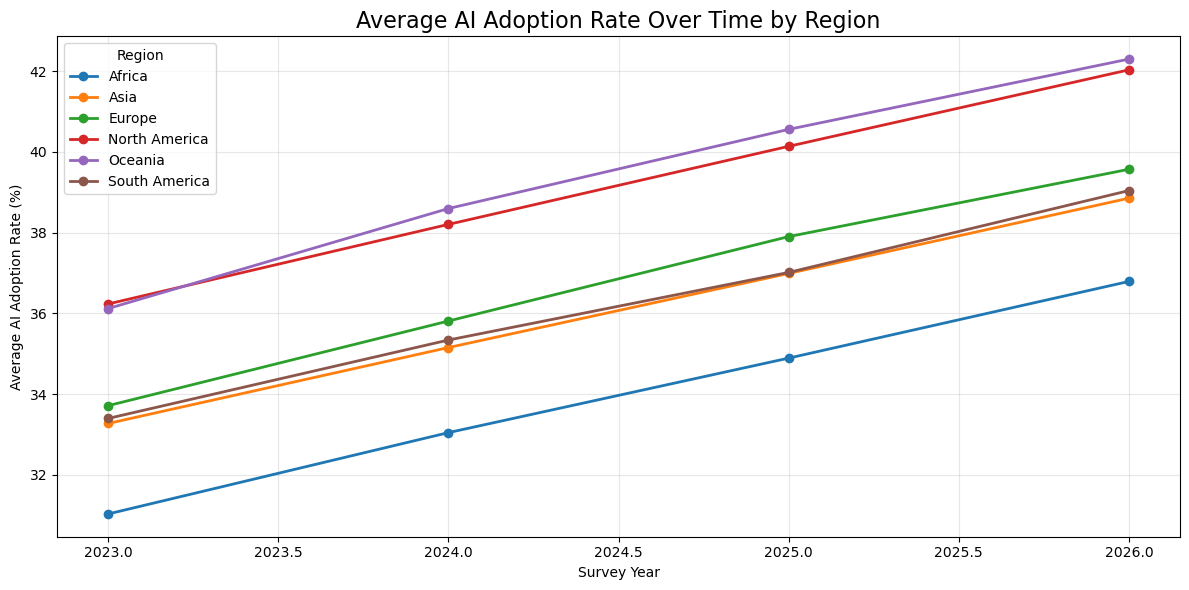

In [130]:
# This plot is not really necessary. It helps show global leaders, but does not really provide
#  anything super valuable other than globally there is a steady increase in AI, which is a little too obvious to waste time on
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for region in regional_adoption["region"].unique():

    region_data = regional_adoption[
        regional_adoption["region"] == region
    ]

    plt.plot(
        region_data["survey_year"],
        region_data["ai_adoption_rate"],
        marker="o",
        linewidth=2,
        label=region
    )


plt.title(
    "Average AI Adoption Rate Over Time by Region",
    fontsize=16
)

plt.xlabel("Survey Year")
plt.ylabel("Average AI Adoption Rate (%)")

plt.legend(title="Region")

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [131]:
workforce_size = (
    df_company
    .groupby("company_size")
    [
        [
            "jobs_created",
            "jobs_displaced",
            "reskilled_employees"
        ]
    ]
    .mean()
)

workforce_size

,jobs_created,jobs_displaced,reskilled_employees
company_size,,,
Enterprise,546.694750,514.283551,844.486077
SME,22.776911,22.433463,34.324033
Startup,2.268960,2.259787,3.277869


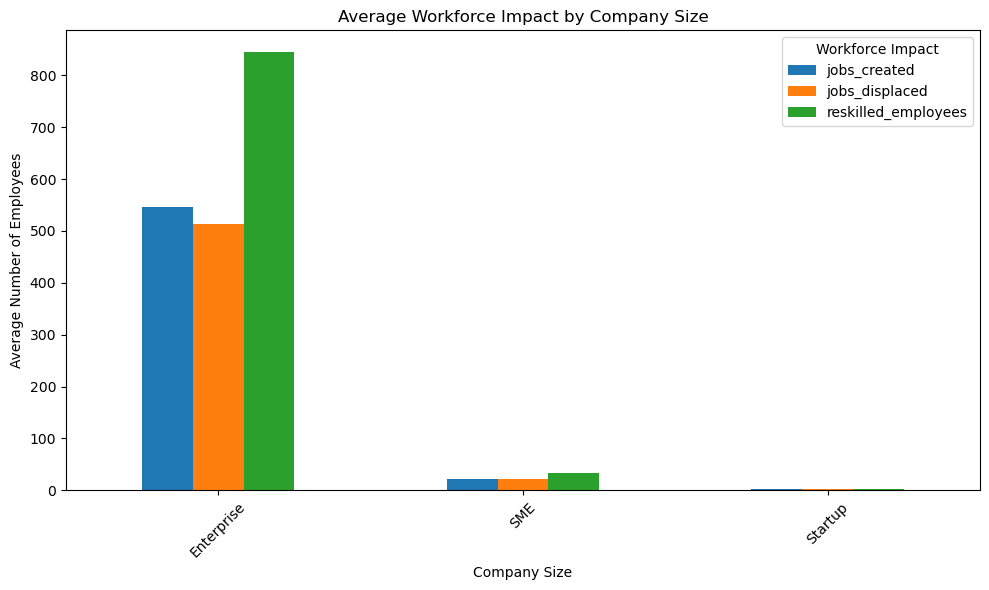

In [132]:
workforce_size.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Workforce Impact by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Average Number of Employees")

plt.xticks(rotation=45)
plt.legend(title="Workforce Impact")

plt.tight_layout()
plt.show()

In [133]:
# Normalize this data by creating a percent
df_company["created_percent"] = (
    df_company["jobs_created"]
    / df_company["num_employees"]
    * 100
)

df_company["displaced_percent"] = (
    df_company["jobs_displaced"]
    / df_company["num_employees"]
    * 100
)

df_company["reskilled_percent"] = (
    df_company["reskilled_employees"]
    / df_company["num_employees"]
    * 100
)

In [134]:
workforce_percent = (
    df_company
    .groupby("company_size")
    [
        [
            "created_percent",
            "displaced_percent",
            "reskilled_percent"
        ]
    ]
    .mean()
)

workforce_percent

,created_percent,displaced_percent,reskilled_percent
company_size,,,
Enterprise,5.170532,4.862986,7.983460
SME,4.182163,4.116980,6.314984
Startup,4.145696,4.121613,5.992857


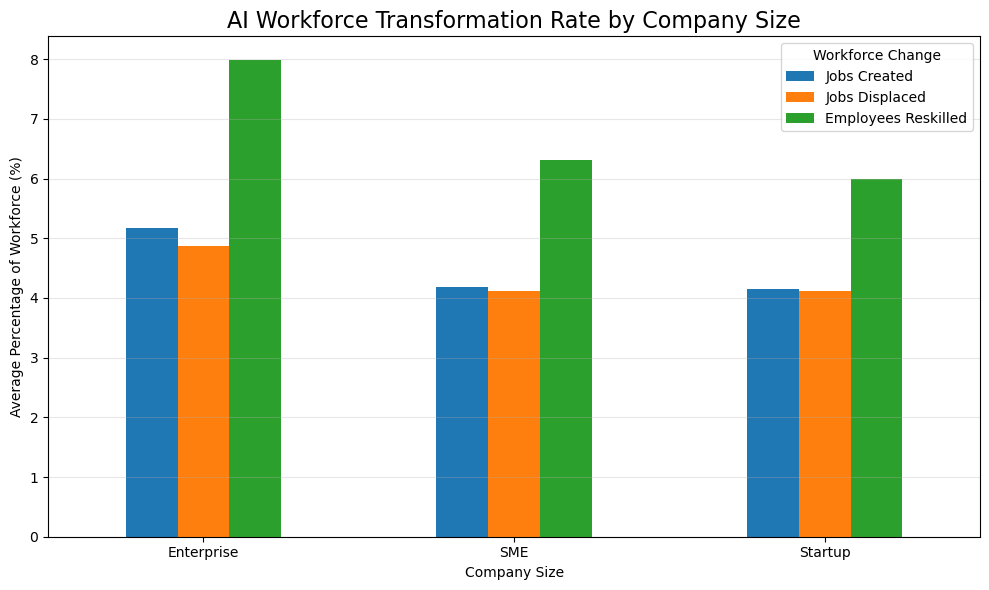

In [135]:
import matplotlib.pyplot as plt

ax = workforce_percent.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "AI Workforce Transformation Rate by Company Size",
    fontsize=16
)

plt.xlabel("Company Size")
plt.ylabel("Average Percentage of Workforce (%)")

plt.xticks(rotation=0)

plt.legend(
    [
        "Jobs Created",
        "Jobs Displaced",
        "Employees Reskilled"
    ],
    title="Workforce Change"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

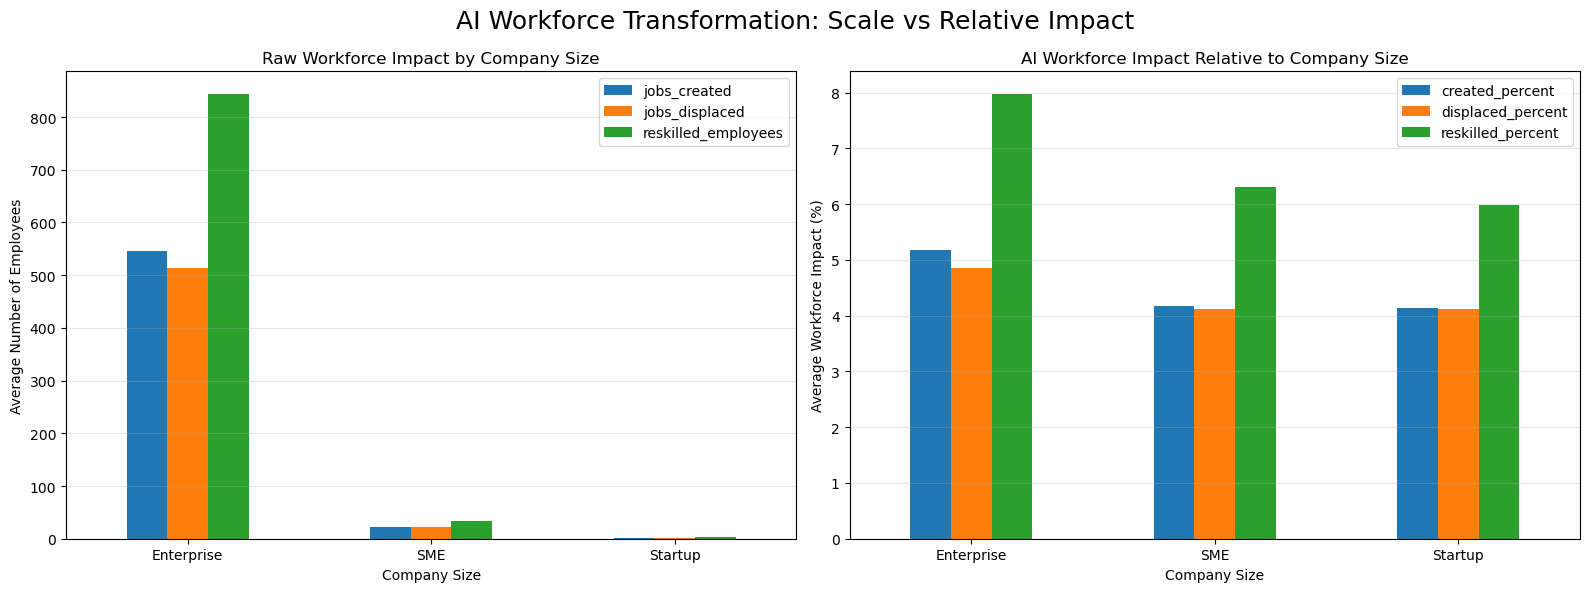

In [179]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16,6)
)


# Raw employee counts
workforce_size.plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title(
    "Raw Workforce Impact by Company Size"
)

axes[0].set_xlabel(
    "Company Size"
)

axes[0].set_ylabel(
    "Average Number of Employees"
)

axes[0].tick_params(
    axis="x",
    rotation=0
)

axes[0].grid(
    axis="y",
    alpha=0.3
)

# Normalized percentages
workforce_percent.plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title(
    "AI Workforce Impact Relative to Company Size"
)

axes[1].set_xlabel(
    "Company Size"
)

axes[1].set_ylabel(
    "Average Workforce Impact (%)"
)

axes[1].tick_params(
    axis="x",
    rotation=0
)

axes[1].grid(
    axis="y",
    alpha=0.3
)


plt.suptitle(
    "AI Workforce Transformation: Scale vs Relative Impact",
    fontsize=18
)

plt.tight_layout()

plt.show()

In [181]:
workforce_size = workforce_size.rename(
    columns={
        "jobs_created": "Jobs Created",
        "jobs_displaced": "Jobs Displaced",
        "reskilled_employees": "Employees Reskilled"
    }
)

workforce_percent = workforce_percent.rename(
    columns={
        "created_percent": "Jobs Created",
        "displaced_percent": "Jobs Displaced",
        "reskilled_percent": "Employees Reskilled"
    }
)

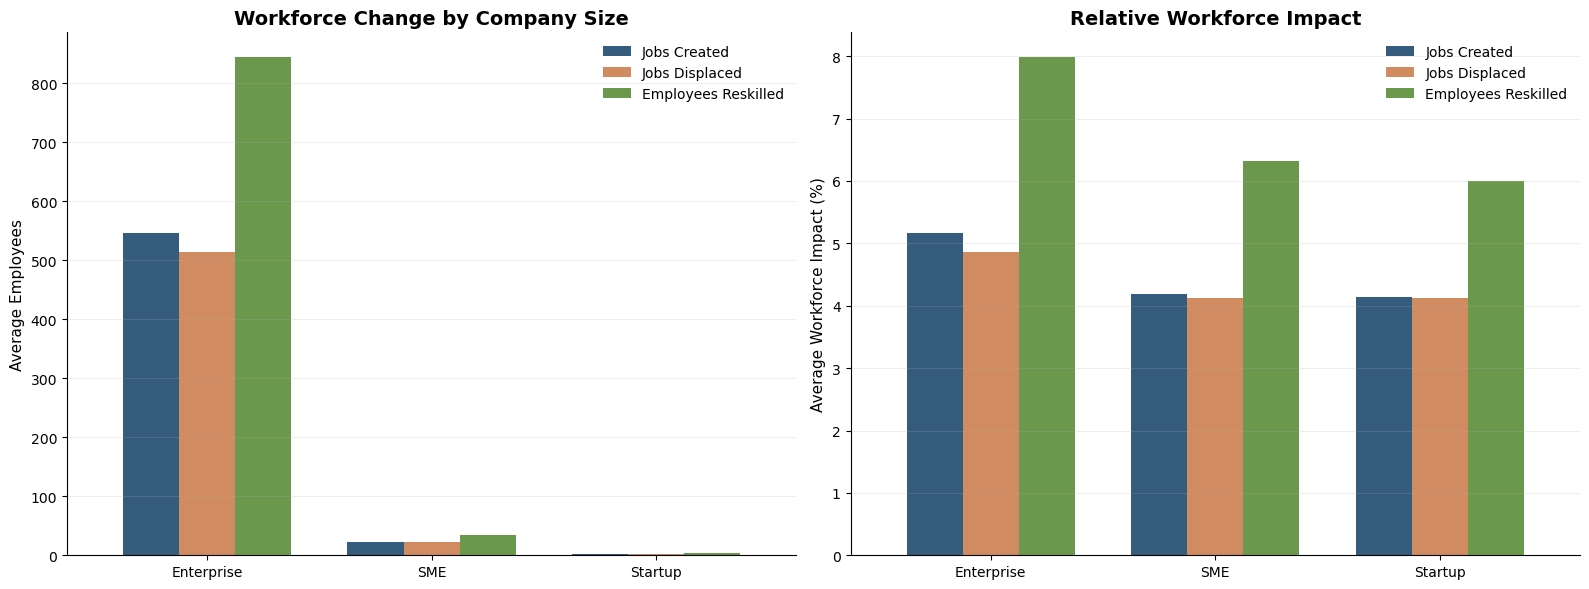

In [193]:
import matplotlib.pyplot as plt

# bar colors
colors = [
    "#355C7D",
    "#D08C60", 
    "#6A994E"  
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

# ----- Raw employee counts -----

workforce_size.plot(
    kind="bar",
    ax=axes[0],
    color=colors,
    width=0.75
)

axes[0].set_title(
    "Workforce Change by Company Size",
    fontsize=14,
    weight="bold"
)

axes[0].set_xlabel("")
axes[0].set_ylabel(
    "Average Employees",
    fontsize=11
)

axes[0].tick_params(
    axis="x",
    rotation=0
)

axes[0].grid(
    axis="y",
    alpha=0.2
)

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)


# ----- Percent impact -----

workforce_percent.plot(
    kind="bar",
    ax=axes[1],
    color=colors,
    width=0.75
)

axes[1].set_title(
    "Relative Workforce Impact",
    fontsize=14,
    weight="bold"
)

axes[1].set_xlabel("")
axes[1].set_ylabel(
    "Average Workforce Impact (%)",
    fontsize=11
)

axes[1].tick_params(
    axis="x",
    rotation=0
)

axes[1].grid(
    axis="y",
    alpha=0.2
)

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)


# Cleaner legends
for ax in axes:
    ax.legend(
        frameon=False,
        fontsize=10
    )

plt.tight_layout()

plt.show()

In [137]:
df_company["net_job_change_percent"] = (
    (df_company["jobs_created"] - df_company["jobs_displaced"])
    / df_company["num_employees"]
    * 100
)

In [138]:
df_company.groupby("company_size")[
    "net_job_change_percent"
].mean()

company_size
Enterprise    0.307546
SME           0.065184
Startup       0.024082
Name: net_job_change_percent, dtype: float64

dataset is not showing a large net change in jobs. all slightly positive.

This next test section is looking at success factors like training and productivity to answer the question   
What factors are associated with successful AI implementation?

In [139]:
success_factors = df_company[
    [
        # Success measures
        "ai_maturity_score",
        "productivity_change_percent",
        "ai_failure_rate",
        "revenue_growth_percent",
        "customer_satisfaction",

        # Possible drivers
        "years_using_ai",
        "ai_training_hours",
        "ai_budget_percentage",
        "num_ai_tools_used",
        "ai_investment_per_employee",
        "regulatory_compliance_score",
        "ai_risk_management_score"
    ]
]

In [140]:
success_corr = success_factors.corr()

success_corr

,ai_maturity_score,productivity_change_percent,ai_failure_rate,revenue_growth_percent,customer_satisfaction,years_using_ai,ai_training_hours,ai_budget_percentage,num_ai_tools_used,ai_investment_per_employee,regulatory_compliance_score,ai_risk_management_score
ai_maturity_score,1.000000,0.737314,-0.697749,0.403190,0.458789,0.155064,0.821696,0.819248,0.454016,0.297108,0.010925,0.445840
productivity_change_percent,0.737314,1.000000,-0.593667,0.476247,0.569821,0.116494,0.633740,0.604105,0.364423,0.218707,0.010039,0.328775
ai_failure_rate,-0.697749,-0.593667,1.000000,-0.322041,-0.434765,-0.098316,-0.739570,-0.527048,-0.351571,-0.194754,-0.003887,-0.312925
revenue_growth_percent,0.403190,0.476247,-0.322041,1.000000,0.277019,0.072800,0.347841,0.340629,0.216696,0.121861,0.009992,0.180570
customer_satisfaction,0.458789,0.569821,-0.434765,0.277019,1.000000,0.068908,0.415638,0.368443,0.226932,0.132962,0.007297,0.204855
years_using_ai,0.155064,0.116494,-0.098316,0.072800,0.068908,1.000000,0.134539,0.138527,0.118055,0.043809,0.005332,0.065638
ai_training_hours,0.821696,0.633740,-0.739570,0.347841,0.415638,0.134539,1.000000,0.560236,0.393811,0.204215,0.008030,0.365538
ai_budget_percentage,0.819248,0.604105,-0.527048,0.340629,0.368443,0.138527,0.560236,1.000000,0.400556,0.350236,0.010780,0.367073
num_ai_tools_used,0.454016,0.364423,-0.351571,0.216696,0.226932,0.118055,0.393811,0.400556,1.000000,0.143924,0.006523,0.201708
ai_investment_per_employee,0.297108,0.218707,-0.194754,0.121861,0.132962,0.043809,0.204215,0.350236,0.143924,1.000000,0.001123,0.136389


In [141]:
success_corr["ai_maturity_score"].sort_values(
    ascending=False
)

ai_maturity_score              1.000000
ai_training_hours              0.821696
ai_budget_percentage           0.819248
productivity_change_percent    0.737314
customer_satisfaction          0.458789
num_ai_tools_used              0.454016
ai_risk_management_score       0.445840
revenue_growth_percent         0.403190
ai_investment_per_employee     0.297108
years_using_ai                 0.155064
regulatory_compliance_score    0.010925
ai_failure_rate               -0.697749
Name: ai_maturity_score, dtype: float64

In [142]:
success_corr["productivity_change_percent"].sort_values(
    ascending=False
)

productivity_change_percent    1.000000
ai_maturity_score              0.737314
ai_training_hours              0.633740
ai_budget_percentage           0.604105
customer_satisfaction          0.569821
revenue_growth_percent         0.476247
num_ai_tools_used              0.364423
ai_risk_management_score       0.328775
ai_investment_per_employee     0.218707
years_using_ai                 0.116494
regulatory_compliance_score    0.010039
ai_failure_rate               -0.593667
Name: productivity_change_percent, dtype: float64

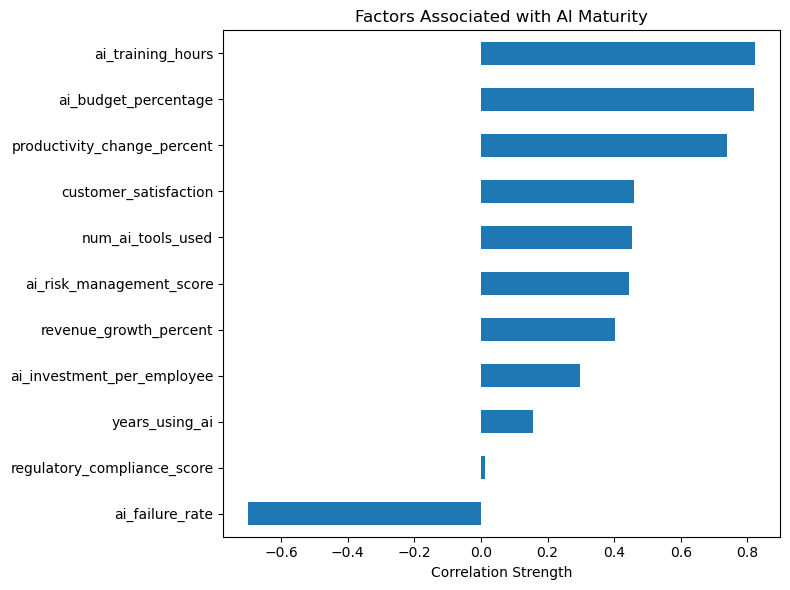

In [143]:
maturity_corr = (
    success_corr["ai_maturity_score"]
    .drop("ai_maturity_score")
    .sort_values()
)

maturity_corr.plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Factors Associated with AI Maturity")
plt.xlabel("Correlation Strength")

plt.tight_layout()
plt.show()

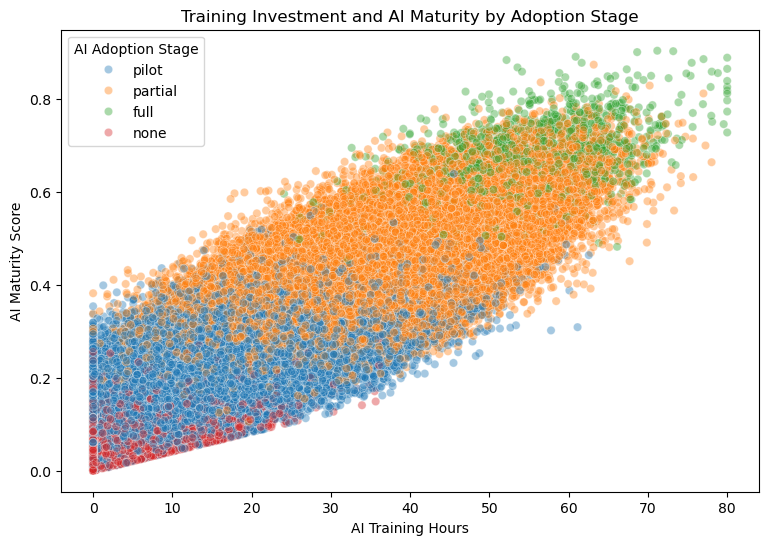

In [144]:
# This really just looks like too much data
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df_company,
    x="ai_training_hours",
    y="ai_maturity_score",
    hue="ai_adoption_stage",
    alpha=.4
)

plt.title("Training Investment and AI Maturity by Adoption Stage")
plt.xlabel("AI Training Hours")
plt.ylabel("AI Maturity Score")

plt.legend(
    title="AI Adoption Stage"
)

plt.show()

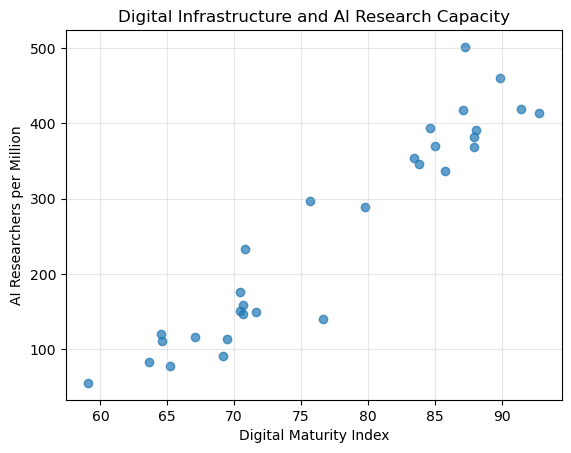

In [145]:
# not sure i care about this
plt.scatter(
    df_country["digital_maturity_index"],
    df_country["ai_researchers_per_million"],
    alpha=.7
)

plt.title("Digital Infrastructure and AI Research Capacity")
plt.xlabel("Digital Maturity Index")
plt.ylabel("AI Researchers per Million")

plt.grid(alpha=.3)

plt.show()

In [146]:
business_success = df_company[
    [
        # outcomes
        "productivity_change_percent",
        "cost_reduction_percent",
        "revenue_growth_percent",
        "innovation_score",
        "customer_satisfaction",
        "employee_satisfaction_score",

        # possible drivers
        "ai_adoption_rate",
        "ai_maturity_score",
        "ai_training_hours",
        "ai_budget_percentage",
        "ai_investment_per_employee",
        "num_ai_tools_used",
        "ai_projects_active",
        "ai_risk_management_score"
    ]
]

business_corr = business_success.corr()

In [147]:
# What correlates with productivity
business_corr[
    "productivity_change_percent"
].sort_values(
    ascending=False
)

productivity_change_percent    1.000000
ai_maturity_score              0.737314
ai_adoption_rate               0.674973
ai_training_hours              0.633740
ai_budget_percentage           0.604105
customer_satisfaction          0.569821
ai_projects_active             0.566833
revenue_growth_percent         0.476247
innovation_score               0.405074
num_ai_tools_used              0.364423
cost_reduction_percent         0.345855
ai_risk_management_score       0.328775
employee_satisfaction_score    0.290436
ai_investment_per_employee     0.218707
Name: productivity_change_percent, dtype: float64

In [148]:
# What correlates with cost reduction
business_corr[
    "cost_reduction_percent"
].sort_values(
    ascending=False
)

cost_reduction_percent         1.000000
ai_adoption_rate               0.404302
ai_maturity_score              0.386162
productivity_change_percent    0.345855
ai_budget_percentage           0.328713
ai_training_hours              0.328314
ai_projects_active             0.289453
innovation_score               0.222638
num_ai_tools_used              0.218866
customer_satisfaction          0.205888
revenue_growth_percent         0.190982
ai_risk_management_score       0.171646
employee_satisfaction_score    0.147959
ai_investment_per_employee     0.117579
Name: cost_reduction_percent, dtype: float64

In [149]:
# What correlates with innovation?
business_corr[
    "innovation_score"
].sort_values(
    ascending=False
)

innovation_score               1.000000
ai_maturity_score              0.531790
ai_adoption_rate               0.509864
ai_budget_percentage           0.445472
ai_training_hours              0.444496
ai_projects_active             0.412083
productivity_change_percent    0.405074
num_ai_tools_used              0.274924
customer_satisfaction          0.248808
ai_risk_management_score       0.236262
revenue_growth_percent         0.230596
cost_reduction_percent         0.222638
employee_satisfaction_score    0.203174
ai_investment_per_employee     0.161687
Name: innovation_score, dtype: float64

In [150]:
business_outcomes = (
    df_company
    .groupby("ai_adoption_stage")
    [
        [
            "productivity_change_percent",
            "revenue_growth_percent",
            "cost_reduction_percent"
        ]
    ]
    .mean()
)

business_outcomes

,productivity_change_percent,revenue_growth_percent,cost_reduction_percent
ai_adoption_stage,,,
full,19.792315,10.491941,8.588315
none,2.391995,0.500773,2.188411
partial,12.026603,6.149891,5.770517
pilot,6.165857,2.893164,3.757529


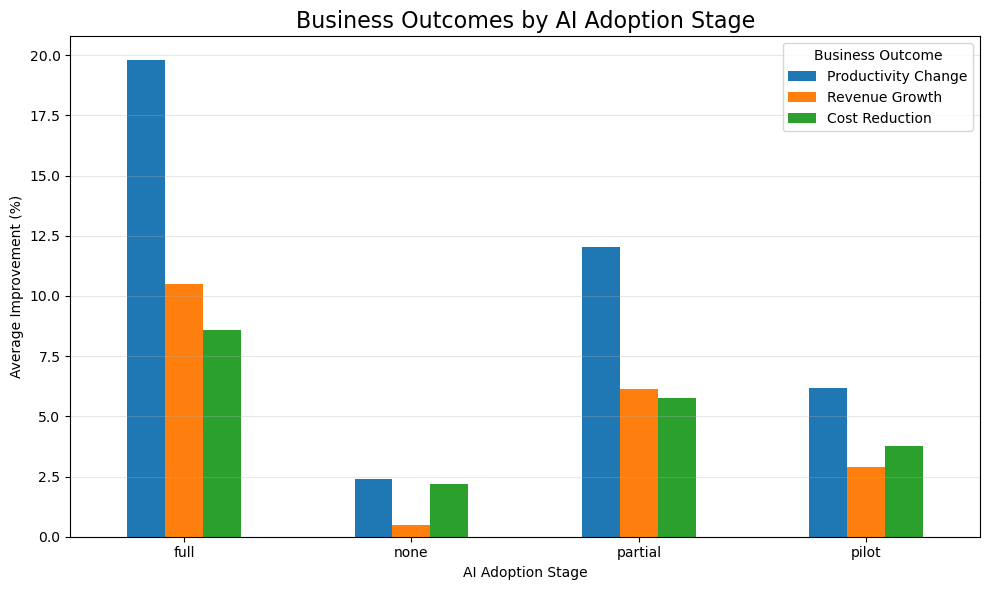

In [151]:
import matplotlib.pyplot as plt

business_outcomes.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Business Outcomes by AI Adoption Stage",
    fontsize=16
)

plt.xlabel(
    "AI Adoption Stage"
)

plt.ylabel(
    "Average Improvement (%)"
)

plt.xticks(
    rotation=0
)

plt.legend(
    [
        "Productivity Change",
        "Revenue Growth",
        "Cost Reduction"
    ],
    title="Business Outcome"
)

plt.grid(
    axis="y",
    alpha=.3
)

plt.tight_layout()

plt.show()

In [152]:
df_company["maturity_group"] = pd.cut(
    df_company["ai_maturity_score"],
    bins=[0,.25,.5,.75,1],
    labels=[
        "Low",
        "Developing",
        "Advanced",
        "High"
    ]
)

In [153]:
maturity_business = (
    df_company
    .groupby("maturity_group")
    [
        [
            "productivity_change_percent",
            "revenue_growth_percent",
            "cost_reduction_percent"
        ]
    ]
    .mean()
)

C:\Users\patri\AppData\Local\Temp\ipykernel_31940\346655041.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [154]:
business_outcomes = (
    df_company
    .groupby("ai_adoption_stage")
    [
        [
            "productivity_change_percent",
            "revenue_growth_percent",
            "cost_reduction_percent"
        ]
    ]
    .mean()
)

business_outcomes

,productivity_change_percent,revenue_growth_percent,cost_reduction_percent
ai_adoption_stage,,,
full,19.792315,10.491941,8.588315
none,2.391995,0.500773,2.188411
partial,12.026603,6.149891,5.770517
pilot,6.165857,2.893164,3.757529


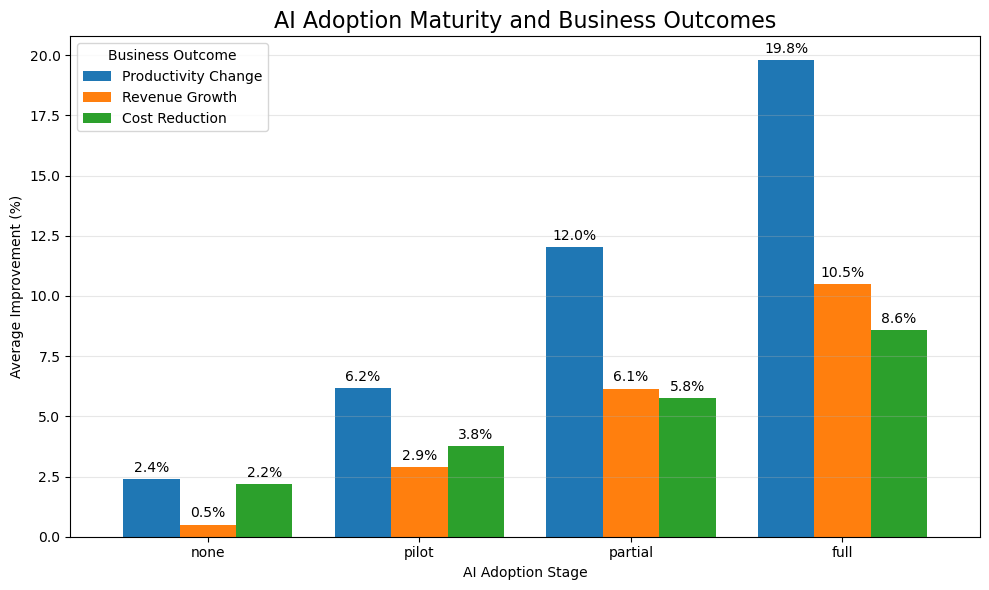

In [155]:
import matplotlib.pyplot as plt

# Calculate average business outcomes by adoption stage
business_outcomes = (
    df_company
    .groupby("ai_adoption_stage")
    [
        [
            "productivity_change_percent",
            "revenue_growth_percent",
            "cost_reduction_percent"
        ]
    ]
    .mean()
)


# Reorder adoption stages logically
stage_order = [
    "none",
    "pilot",
    "partial",
    "full"
]

business_outcomes = business_outcomes.loc[stage_order]


# Create grouped bar chart
ax = business_outcomes.plot(
    kind="bar",
    figsize=(10,6),
    width=.8
)


# Add percentage labels above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )


# Chart formatting
plt.title(
    "AI Adoption Maturity and Business Outcomes",
    fontsize=16
)

plt.xlabel(
    "AI Adoption Stage"
)

plt.ylabel(
    "Average Improvement (%)"
)

plt.xticks(
    rotation=0
)


plt.legend(
    [
        "Productivity Change",
        "Revenue Growth",
        "Cost Reduction"
    ],
    title="Business Outcome"
)


plt.grid(
    axis="y",
    alpha=.3
)


plt.tight_layout()


# Optional: save for README
plt.savefig(
    "../Images/business_outcomes_ai_adoption.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

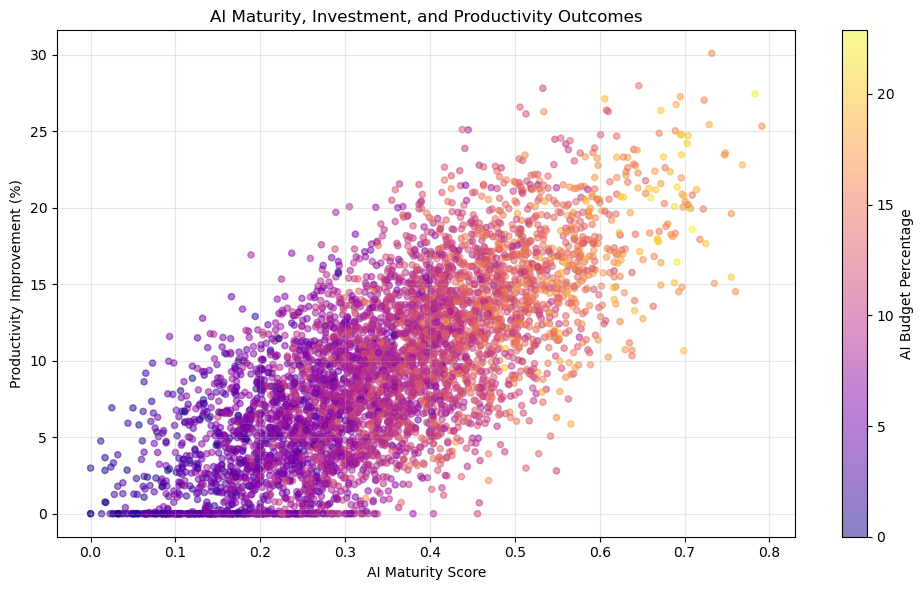

In [156]:
import matplotlib.pyplot as plt

sample = df_company.sample(
    5000,
    random_state=42
)

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    sample["ai_maturity_score"],
    sample["productivity_change_percent"],
    c=sample["ai_budget_percentage"],
    cmap="plasma",
    alpha=.5,
    s=20
)

plt.colorbar(
    scatter,
    label="AI Budget Percentage"
)

plt.title(
    "AI Maturity, Investment, and Productivity Outcomes"
)

plt.xlabel(
    "AI Maturity Score"
)

plt.ylabel(
    "Productivity Improvement (%)"
)

plt.grid(alpha=.3)

plt.tight_layout()

plt.show()

In [157]:
df_company["estimated_ai_adoption_year"] = (
    df_company["survey_year"]
    - df_company["years_using_ai"]
)

df_company[
    [
        "survey_year",
        "years_using_ai",
        "estimated_ai_adoption_year"
    ]
].head()

,survey_year,years_using_ai,estimated_ai_adoption_year
0,2023,3,2020
1,2023,4,2019
2,2023,2,2021
3,2023,2,2021
4,2024,7,2017


In [158]:
adoption_generation = (
    df_company
    .groupby("estimated_ai_adoption_year")
    [
        [
            "ai_maturity_score",
            "productivity_change_percent"
        ]
    ]
    .mean()
)

adoption_generation.head()

,ai_maturity_score,productivity_change_percent
estimated_ai_adoption_year,,
2016,0.351809,9.510686
2017,0.351474,9.470794
2018,0.351176,9.443129
2019,0.351677,9.466654
2020,0.351958,9.469852


In [159]:
experience_curve = (
    df_company
    .groupby("years_using_ai")
    [
        [
            "ai_maturity_score",
            "productivity_change_percent"
        ]
    ]
    .mean()
)

experience_curve

,ai_maturity_score,productivity_change_percent
years_using_ai,,
0,0.115624,2.391995
1,0.345305,9.229677
2,0.344760,9.206160
3,0.352417,9.515044
4,0.351376,9.467391
5,0.352264,9.466636
6,0.351944,9.481198
7,0.352881,9.435498
8,0.358290,9.743936


In [160]:
quarter_map = {
    "Q1": "01",
    "Q2": "04",
    "Q3": "07",
    "Q4": "10"
}

df_company["survey_period"] = pd.to_datetime(
    df_company["survey_year"].astype(str)
    + "-"
    + df_company["quarter"].map(quarter_map)
    + "-01"
)

In [161]:
industry_time = (
    df_company.groupby(["survey_period", "industry"])
    [["ai_adoption_rate", "productivity_change_percent"]].mean()
    .reset_index()
)

industry_time.head()

,survey_period,industry,ai_adoption_rate,productivity_change_percent
0,2023-01-01,Agriculture,31.057278,7.973681
1,2023-01-01,Consulting,30.544369,7.758363
2,2023-01-01,Education,30.875787,7.768215
3,2023-01-01,Finance,34.296522,8.452198
4,2023-01-01,Healthcare,30.852658,7.838714


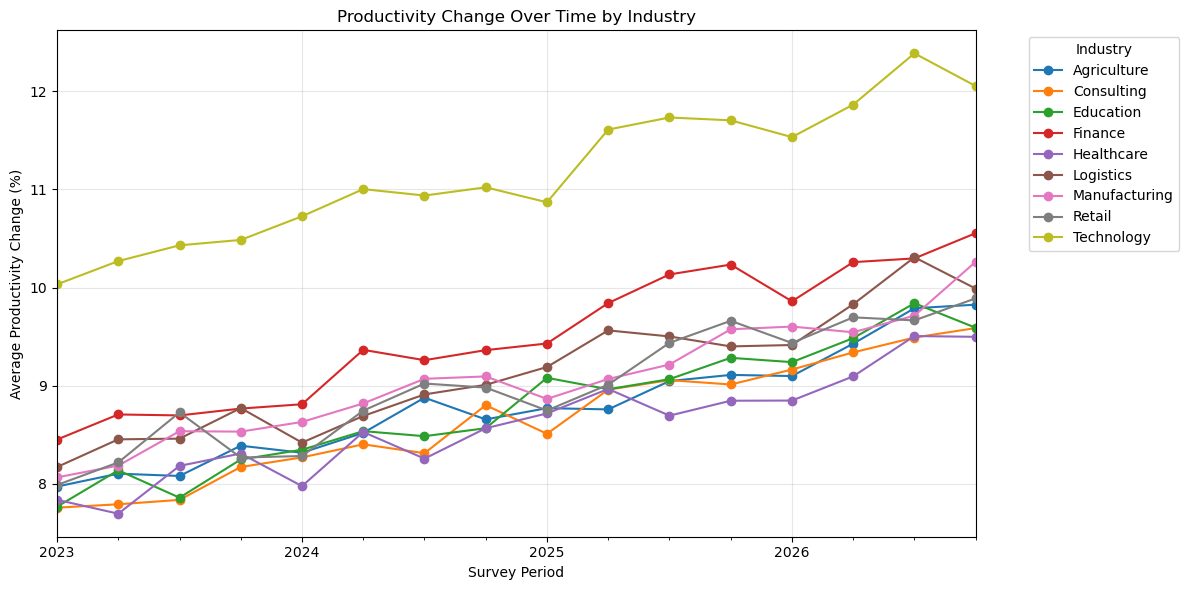

In [162]:
import matplotlib.pyplot as plt

productivity_pivot = industry_time.pivot(
    index="survey_period",
    columns="industry",
    values="productivity_change_percent"
)

productivity_pivot.plot(
    kind="line",
    marker="o",
    figsize=(12,6)
)

plt.title("Productivity Change Over Time by Industry")
plt.xlabel("Survey Period")
plt.ylabel("Average Productivity Change (%)")
plt.grid(alpha=0.3)
plt.legend(title="Industry", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

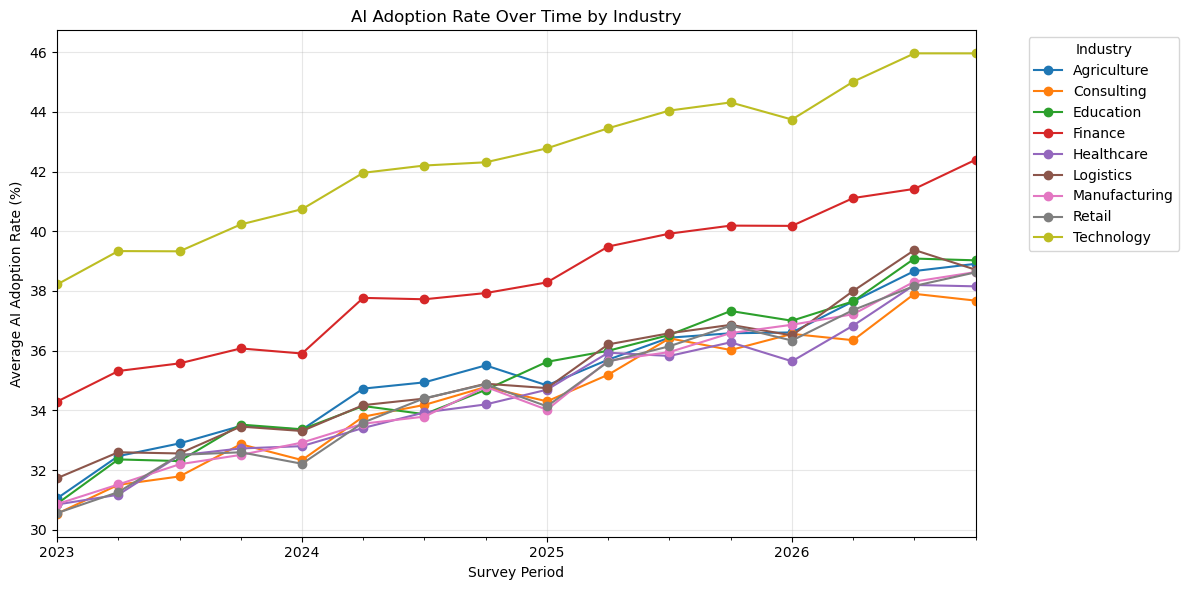

In [163]:
adoption_pivot = industry_time.pivot(
    index="survey_period",
    columns="industry",
    values="ai_adoption_rate"
)

adoption_pivot.plot(
    kind="line",
    marker="o",
    figsize=(12,6)
)

plt.title("AI Adoption Rate Over Time by Industry")
plt.xlabel("Survey Period")
plt.ylabel("Average AI Adoption Rate (%)")
plt.grid(alpha=0.3)
plt.legend(title="Industry", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [164]:
df_company["survey_year"].sort_values().unique()

array([2023, 2024, 2025, 2026])

In [165]:
from scipy.stats import pearsonr

r, p = pearsonr(
    df_company["ai_maturity_score"],
    df_company["productivity_change_percent"]
)

print("Correlation:", r)
print("P-value:", p)

Correlation: 0.7373138002177632
P-value: 0.0


In [166]:
industry_comparison = (
    df_company
    .groupby("industry")
    [["ai_adoption_rate","productivity_change_percent","ai_maturity_score", "ai_training_hours"]]
    .mean()
    .sort_values("productivity_change_percent", ascending=False)
    )

industry_comparison

,ai_adoption_rate,productivity_change_percent,ai_maturity_score,ai_training_hours
industry,,,,
Technology,42.470735,11.166343,0.410003,31.003907
Finance,38.348494,9.502793,0.354865,28.473983
Logistics,35.262117,9.131974,0.332153,26.352100
Manufacturing,34.727883,9.052698,0.329277,26.152743
Retail,34.699815,8.985443,0.327464,26.007850
Agriculture,35.251479,8.800457,0.332237,26.443478
Education,35.225152,8.785513,0.334276,26.652257
Consulting,34.516004,8.654856,0.327678,25.990765
Healthcare,34.570853,8.595936,0.328216,26.083821


In [167]:
industry_ai_value = (
    df_company
    .groupby("industry")
    [["ai_adoption_rate",
    "productivity_change_percent",
    "ai_budget_percentage",
    "ai_maturity_score"]].mean()
    .reset_index()
)

industry_ai_value

,industry,ai_adoption_rate,productivity_change_percent,ai_budget_percentage,ai_maturity_score
0,Agriculture,35.251479,8.800457,9.052703,0.332237
1,Consulting,34.516004,8.654856,8.917910,0.327678
2,Education,35.225152,8.785513,9.043360,0.334276
3,Finance,38.348494,9.502793,9.564347,0.354865
4,Healthcare,34.570853,8.595936,8.934193,0.328216
5,Logistics,35.262117,9.131974,9.014707,0.332153
6,Manufacturing,34.727883,9.052698,8.969758,0.329277
7,Retail,34.699815,8.985443,8.928646,0.327464
8,Technology,42.470735,11.166343,12.191900,0.410003


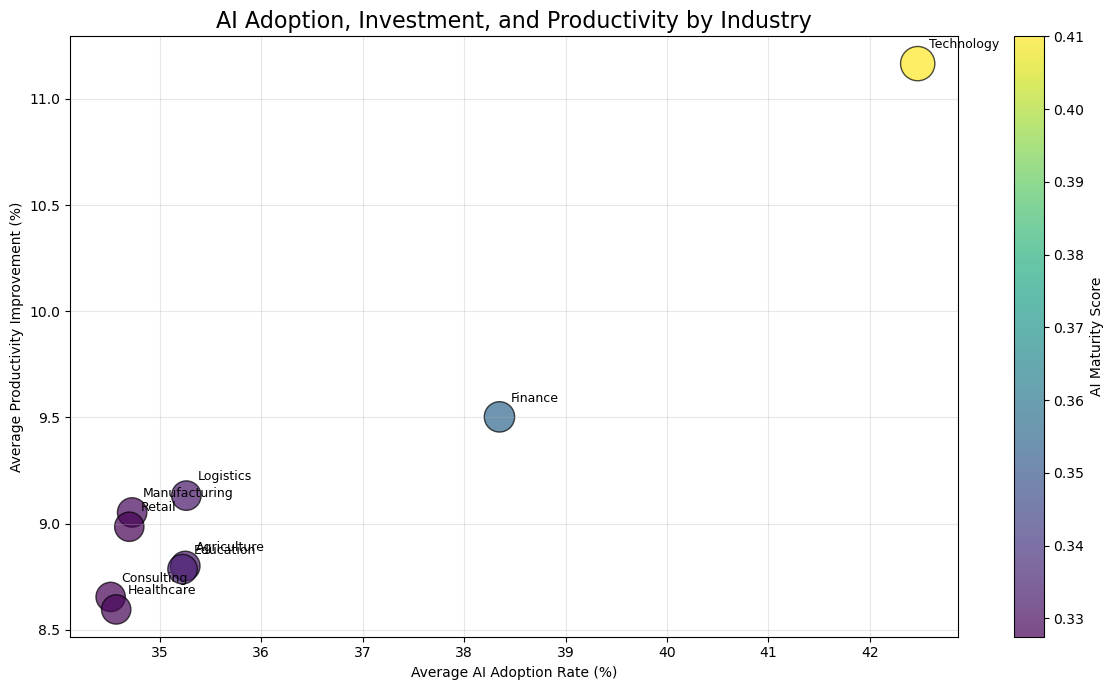

In [168]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(12,7)
)

scatter = plt.scatter(
    industry_ai_value["ai_adoption_rate"],
    industry_ai_value["productivity_change_percent"],
    s=industry_ai_value["ai_budget_percentage"] * 50,
    c=industry_ai_value["ai_maturity_score"],
    cmap="viridis",
    alpha=.7,
    edgecolors="black"
)
plt.colorbar(
    scatter,
    label="AI Maturity Score"
)
plt.title(
    "AI Adoption, Investment, and Productivity by Industry",
    fontsize=16
)
plt.xlabel(
    "Average AI Adoption Rate (%)"
)
plt.ylabel(
    "Average Productivity Improvement (%)"
)
plt.grid(
    alpha=.3
)
plt.tight_layout()
for i, row in industry_ai_value.iterrows():
    plt.annotate(
        row["industry"],
        (
            row["ai_adoption_rate"],
            row["productivity_change_percent"]
        ),
        xytext=(8,11),
        textcoords="offset points",
        fontsize=9
    )
plt.show()

In [169]:
import plotly.express as px

fig = px.scatter(
    industry_ai_value,
    x="ai_adoption_rate",
    y="productivity_change_percent",
    size="ai_budget_percentage",
    color="industry",
    hover_name="industry",
    hover_data=[
        "ai_maturity_score"
    ],
    title="AI Adoption, Investment, and Productivity by Industry"
)

fig.show()

In [170]:
fig = px.scatter(
    industry_ai_value,
    x="ai_adoption_rate",
    y="productivity_change_percent",
    size="ai_budget_percentage",
    color="industry",
    hover_name="industry",
    hover_data={
        "ai_adoption_rate":":.1f",
        "productivity_change_percent":":.1f",
        "ai_budget_percentage":":.1f",
        "ai_maturity_score":":.2f"
    },
    size_max=45,
    title="AI Adoption, Investment, and Productivity by Industry",
    labels={
        "ai_adoption_rate":"AI Adoption Rate (%)",
        "productivity_change_percent":"Productivity Improvement (%)",
        "ai_budget_percentage":"AI Budget (%)",
        "industry":"Industry"
    }
)

In [171]:
import plotly.express as px

industry_ai_value = (
    df_company
    .groupby("industry")
    [
        [
            "ai_adoption_rate",
            "productivity_change_percent",
            "ai_budget_percentage",
            "ai_maturity_score"
        ]
    ]
    .mean()
    .reset_index()
)

fig = px.scatter(
    industry_ai_value,
    x="ai_adoption_rate",
    y="productivity_change_percent",
    size="ai_budget_percentage",
    color="industry",
    text="industry",
    hover_name="industry",
    hover_data={
        "ai_adoption_rate":":.1f",
        "productivity_change_percent":":.1f",
        "ai_budget_percentage":":.1f",
        "ai_maturity_score":":.2f"
    },
    size_max=55,
    title="Technology and Finance Lead in AI Adoption and Productivity Gains",
    labels={
        "ai_adoption_rate":"Average AI Adoption Rate (%)",
        "productivity_change_percent":"Average Productivity Improvement (%)",
        "ai_budget_percentage":"Average AI Budget (%)",
        "ai_maturity_score":"AI Maturity Score",
        "industry":"Industry"
    }
)

fig.update_traces(
    textposition="top center",
    marker=dict(
        opacity=0.75,
        line=dict(width=1, color="white")
    )
)

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=700,
    title={
        "x":0.5,
        "font":{"size":22}
    },
    font=dict(size=14),
    showlegend=False
)

fig.update_xaxes(
    range=[
        industry_ai_value["ai_adoption_rate"].min() - 1,
        industry_ai_value["ai_adoption_rate"].max() + 1
    ]
)

fig.update_yaxes(
    range=[
        industry_ai_value["productivity_change_percent"].min() - .5,
        industry_ai_value["productivity_change_percent"].max() + .7
    ]
)

fig.show()

In [172]:
df_company["transformation_ratio"] = (
    df_company["jobs_created"] + df_company["reskilled_employees"]
) / df_company["jobs_displaced"]

df_company["transformation_ratio"]

0         4.000000
1         3.500000
2         1.666667
3         3.000000
4         4.500000
            ...   
149995    2.161765
149996    3.618026
149997    2.391912
149998    1.866716
149999    2.557227
Name: transformation_ratio, Length: 150000, dtype: float64

In [173]:
workforce_summary = (
    df_company
    .groupby("company_size")
    [
        [
            "jobs_created",
            "jobs_displaced",
            "reskilled_employees"
        ]
    ]
    .mean()
    .reset_index()
)

In [178]:
import plotly.express as px

# Create workforce summary
workforce_summary = (
    df_company
    .groupby("company_size")
    [
        [
            "jobs_displaced",
            "jobs_created",
            "reskilled_employees",
            "ai_maturity_score"
        ]
    ]
    .mean()
    .reset_index()
)


fig = px.scatter(
    workforce_summary,
    x="jobs_displaced",
    y="jobs_created",
    size="reskilled_employees",
    color="company_size",
    hover_data=[
        "ai_maturity_score",
        "reskilled_employees"
    ],
    title="AI Workforce Transformation: Creation, Displacement, and Reskilling",
    size_max=80
)

fig.update_layout(
    xaxis_title="Average Jobs Displaced",
    yaxis_title="Average Jobs Created",
    legend_title="Company Size"
)

fig.show()